# Dominio 3: Sector Agrícola (Banco Mundial)

8 indicadores reales del Banco Mundial (`api.worldbank.org`, sin
autenticación) para 9 países sudamericanos, 1990-2025: rendimiento de
cereales (target), fertilizante, tierra arable/agrícola/irrigada, PIB
agrícola, población rural, índice de producción de cultivos.

Este notebook ejecuta el pipeline real de `src/domains/agriculture_worldbank/`.


## 1. Limpieza del panel país×año


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
from src.domains.agriculture_worldbank.clean import build_clean_panel

panel, report = build_clean_panel()
for k, v in report.items():
    if not isinstance(v, pd.DataFrame):
        print(f"{k}: {v}")


Missingness ANTES de limpiar:
                 columna  n_nulos  pct_nulos   dtype
      irrigated_land_pct      274      84.57 float64
   crop_production_index       27       8.33 float64
         arable_land_pct       18       5.56 float64
           agri_land_pct       18       5.56 float64
        fertilizer_kg_ha       18       5.56 float64
      cereal_yield_kg_ha       10       3.09 float64
agri_value_added_gdp_pct        3       0.93 float64
                    year        0       0.00   int64
            country_name        0       0.00  object
            country_iso3        0       0.00  object
           rural_pop_pct        0       0.00 float64

Missingness DESPUÉS de limpiar:
                 columna  n_nulos  pct_nulos   dtype
            country_iso3        0        0.0  object
            country_name        0        0.0  object
                    year        0        0.0   int64
      cereal_yield_kg_ha        0        0.0 float64
         arable_land_pct        0   

**Hallazgo real**: la mayoría de los indicadores están casi completos por
país, pero `AG.LND.IRIG.AG.ZS` (tierra agrícola irrigada) es la excepción
seria -- Perú no tiene NI UN SOLO valor real en 36 años. Un hueco así no es
interpolable (no hay ningún punto de anclaje dentro de la propia serie de
Perú); se resuelve con imputación por media entre países, documentado
explícitamente en vez de disfrazarlo de interpolación.


## 2. Features y modelado (>=100 épocas)


In [2]:
from src.domains.agriculture_worldbank.features import build_features

features_df = build_features(panel)
print(f"{len(features_df):,} filas x features")
features_df.describe().T


297 filas x features


,count,mean,std,min,25%,50%,75%,max
year,297.0,2009.000000,9.537975,1993.000000,2001.000000,2009.000000,2017.000000,2025.000000
cereal_yield_kg_ha,297.0,3687.988889,1277.426441,1366.500000,2683.900000,3643.300000,4482.500000,7157.200000
arable_land_pct,297.0,6.024025,3.892091,1.325225,2.935020,5.092401,8.253041,15.748587
fertilizer_kg_ha,297.0,162.440352,142.693098,0.631922,50.188521,129.152692,240.181955,699.090455
agri_land_pct,297.0,37.911846,18.974198,14.319933,22.044613,34.653477,44.784657,85.487373
crop_production_index,297.0,81.440539,23.220862,32.790000,63.930000,84.380000,100.200000,130.740000
rural_pop_pct,297.0,22.721663,12.094830,4.346281,12.104145,22.166043,34.893267,47.431723
irrigated_land_pct,297.0,3.490632,4.267942,0.483185,0.944369,1.451727,3.434310,23.410621
agri_value_added_gdp_pct,297.0,8.192753,3.640482,3.236047,5.711485,7.444784,9.740218,23.403159
cereal_yield_lag1,297.0,3622.540404,1277.135099,1366.500000,2617.300000,3552.600000,4422.200000,7157.200000


In [3]:
import json
metrics = json.load(open("../outputs/agriculture/metrics.json"))
pd.DataFrame(metrics["results"]).T


,r2,rmse,mae,epochs_run,best_epoch,early_stopped,best_iteration,alpha_relativo,alpha_efectivo,l1_ratio,...,n_coeficientes,n_coeficientes_no_nulos,max_depth,min_samples_leaf,n_estimators,features_mas_importantes,window,hidden,n_secuencias_train,n_test_con_relleno
baseline_media_pais,-0.327073,1283.051155,1193.94058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mlp_pytorch,0.872354,397.924192,310.737926,330,305,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,0.8839,379.500109,301.769679,NaN,NaN,NaN,401.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elasticnet,0.842177,442.468386,356.928128,NaN,NaN,NaN,NaN,0.001,1.148714,0.0,...,21.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random_forest,0.904409,344.354316,256.417106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4,2,300,"[{'feature': 'cereal_yield_rolling3', 'importa...",NaN,NaN,NaN,NaN
lstm,0.798996,499.342717,389.834138,100,75,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5,32,171,0


**Resultado real**: tanto la MLP (R²=0.87) como XGBoost (R²=0.88) superan
ampliamente al baseline (R²=-0.33, negativo porque el rendimiento de
cereales tiene una tendencia real al alza que un promedio histórico
subestima) -- acá SÍ hay señal real y fuerte (fertilizante, tierra irrigada,
tendencia agronómica), a diferencia del dominio financiero.


## 3. Gráficos


**% de nulos por indicador, antes/después de interpolar** -- muestra el caso extremo de tierra irrigada.


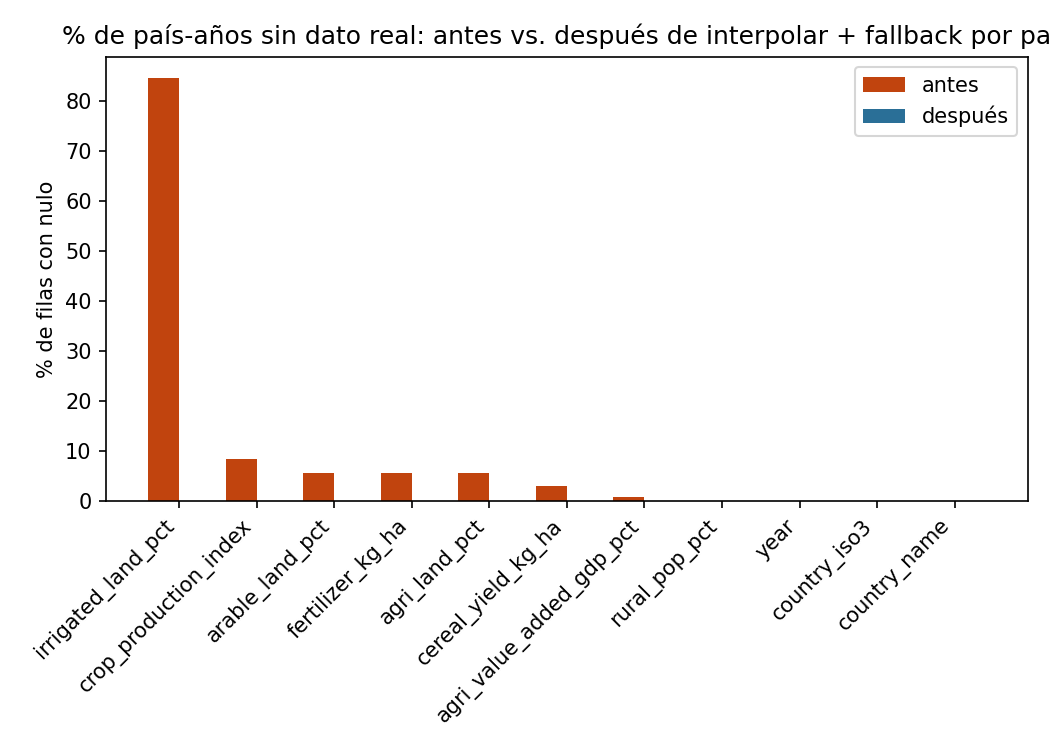

In [4]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/missingness_before_after.png"))


**Correlación entre features y el rendimiento de cereales del año siguiente.**


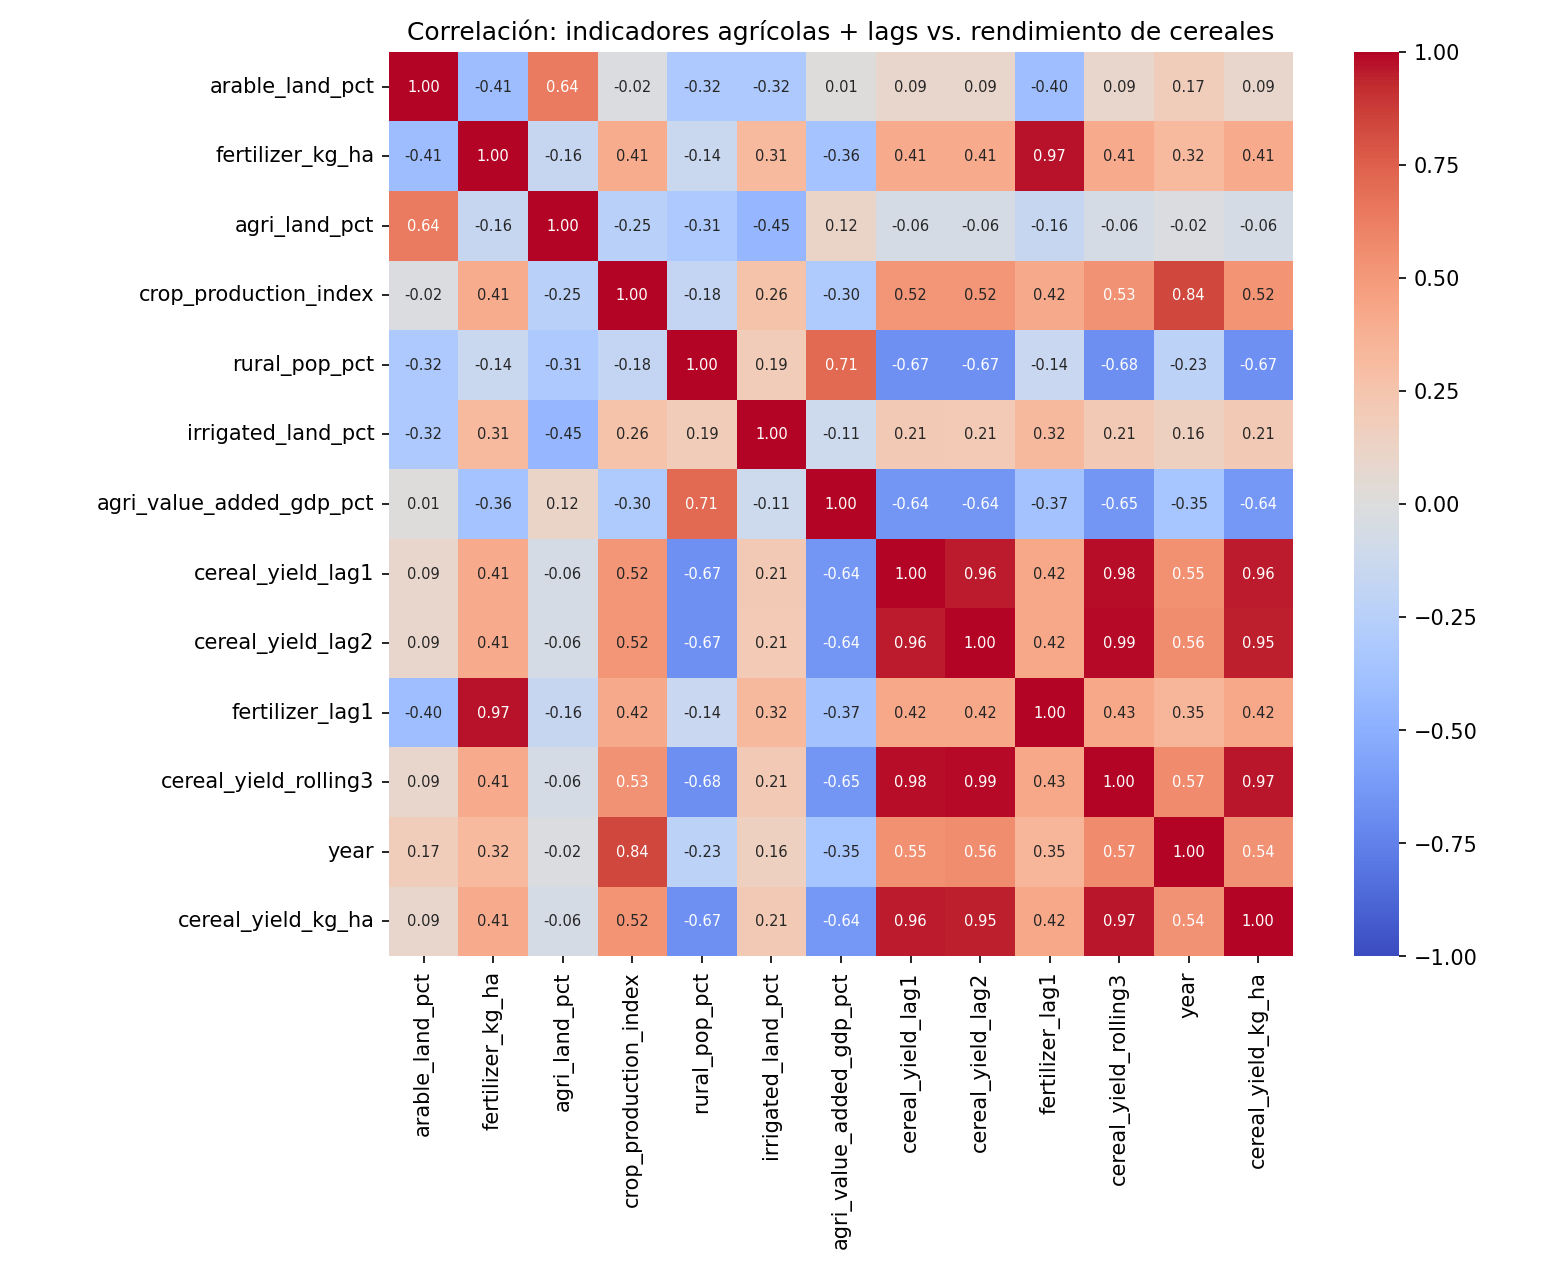

In [5]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/feature_correlation.png"))


**Rendimiento de cereales real, Chile, 1990-2025.**


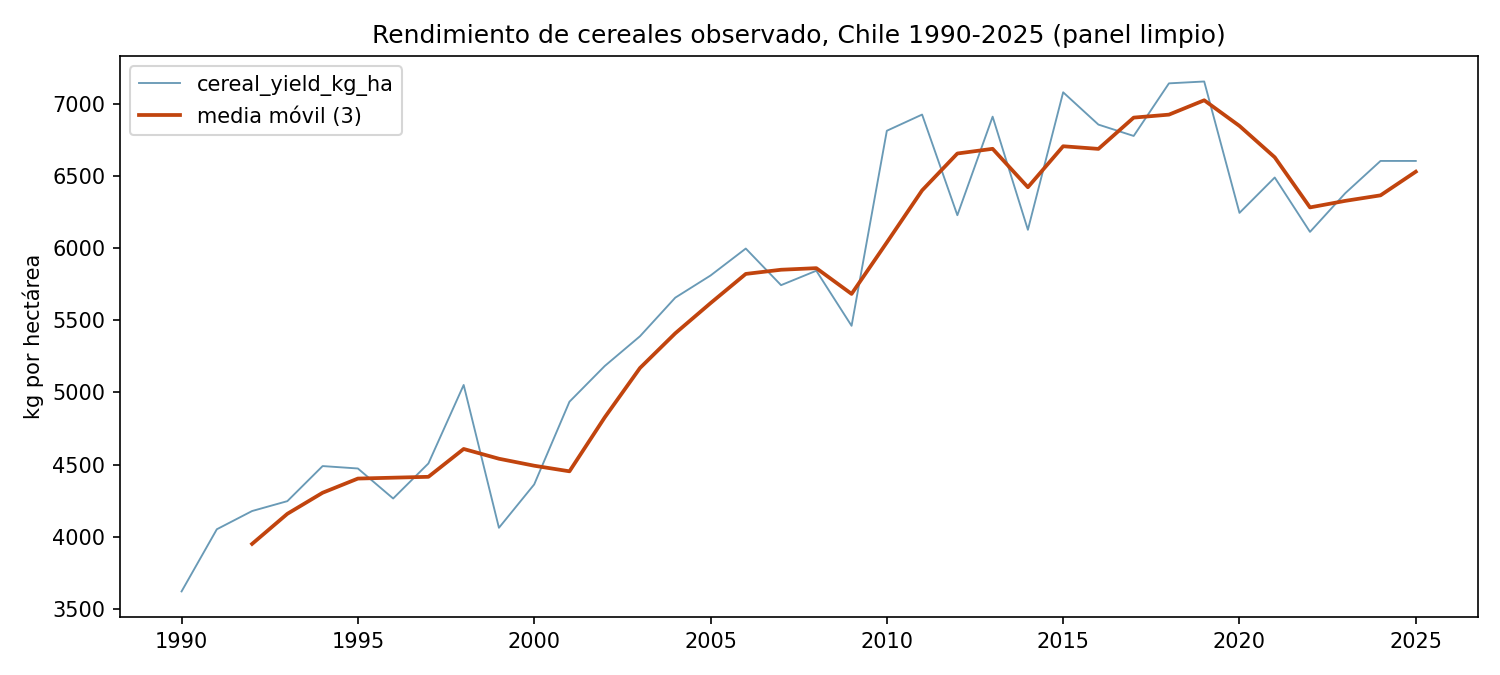

In [6]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/cereal_yield_timeseries_CHL.png"))


**Rendimiento de cereales real, Argentina, 1990-2025.**


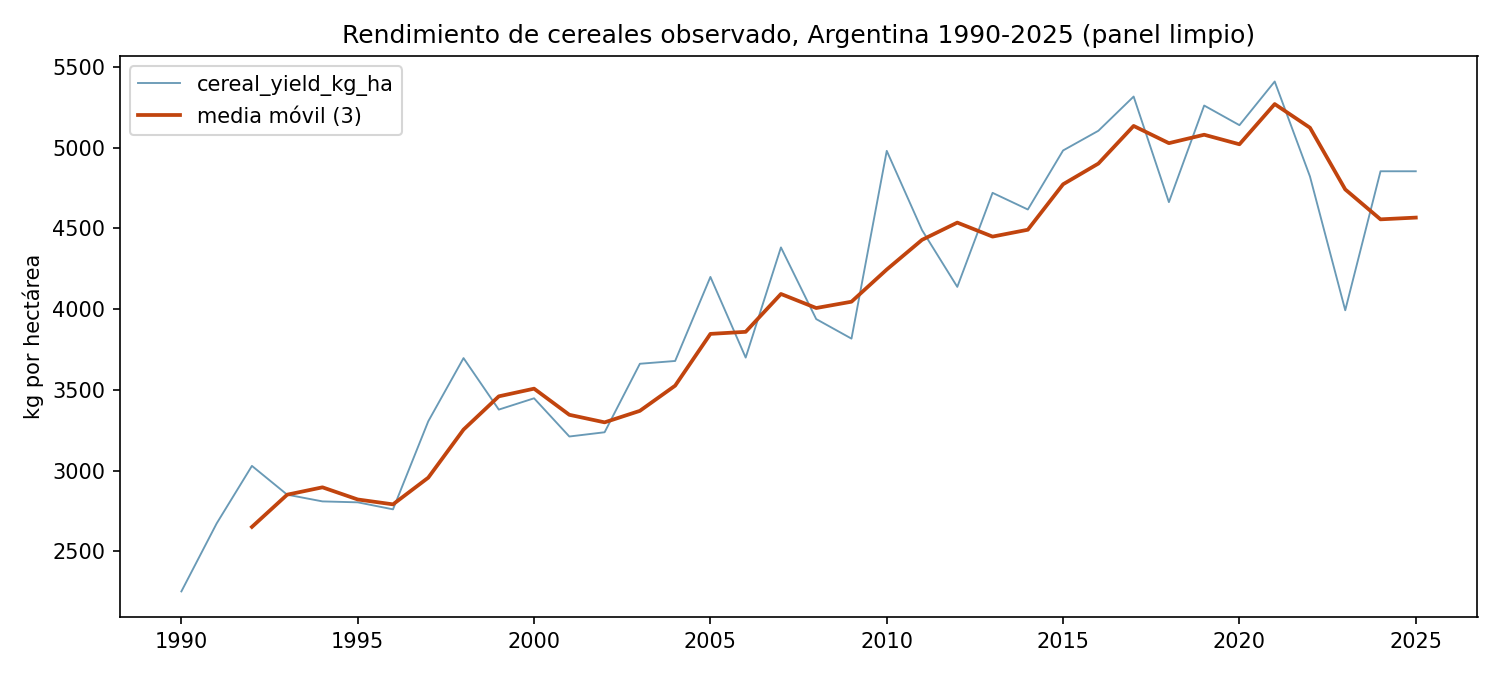

In [7]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/cereal_yield_timeseries_ARG.png"))


**Curva de entrenamiento de la MLP** -- >=100 épocas, con early stopping real (mejor época marcada).


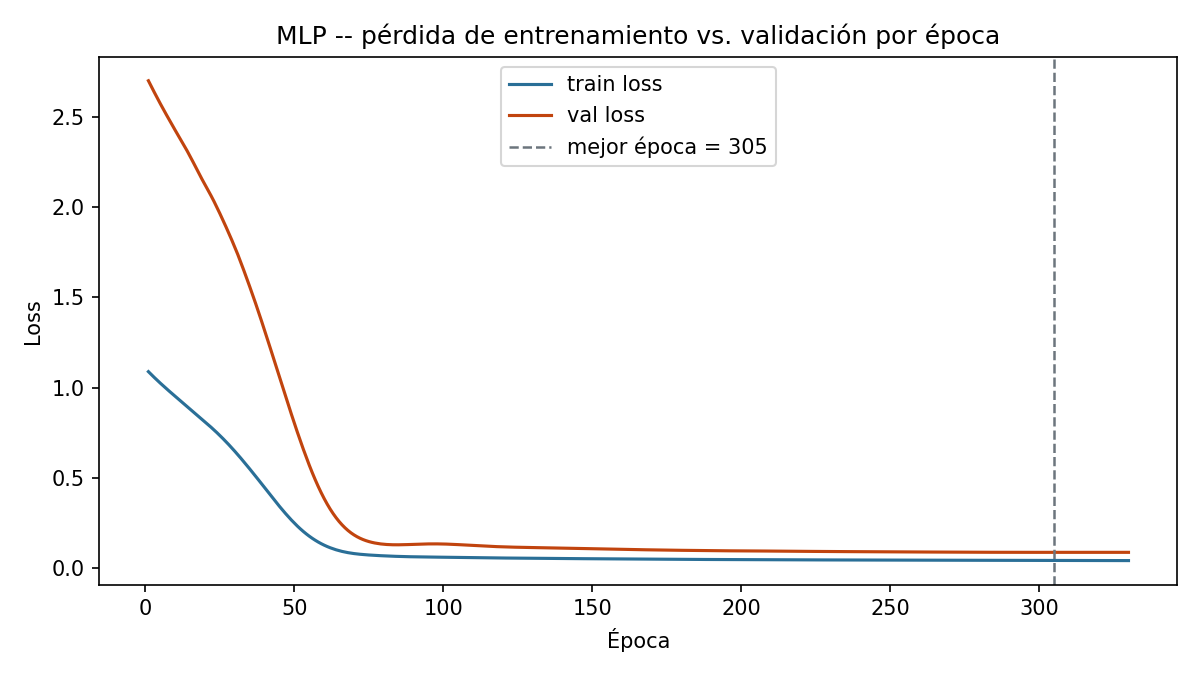

In [8]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/mlp_training_curve.png"))


**Rendimiento real vs. predicho, mejor de los 6 modelos (Random Forest, holdout 2020-2025).**


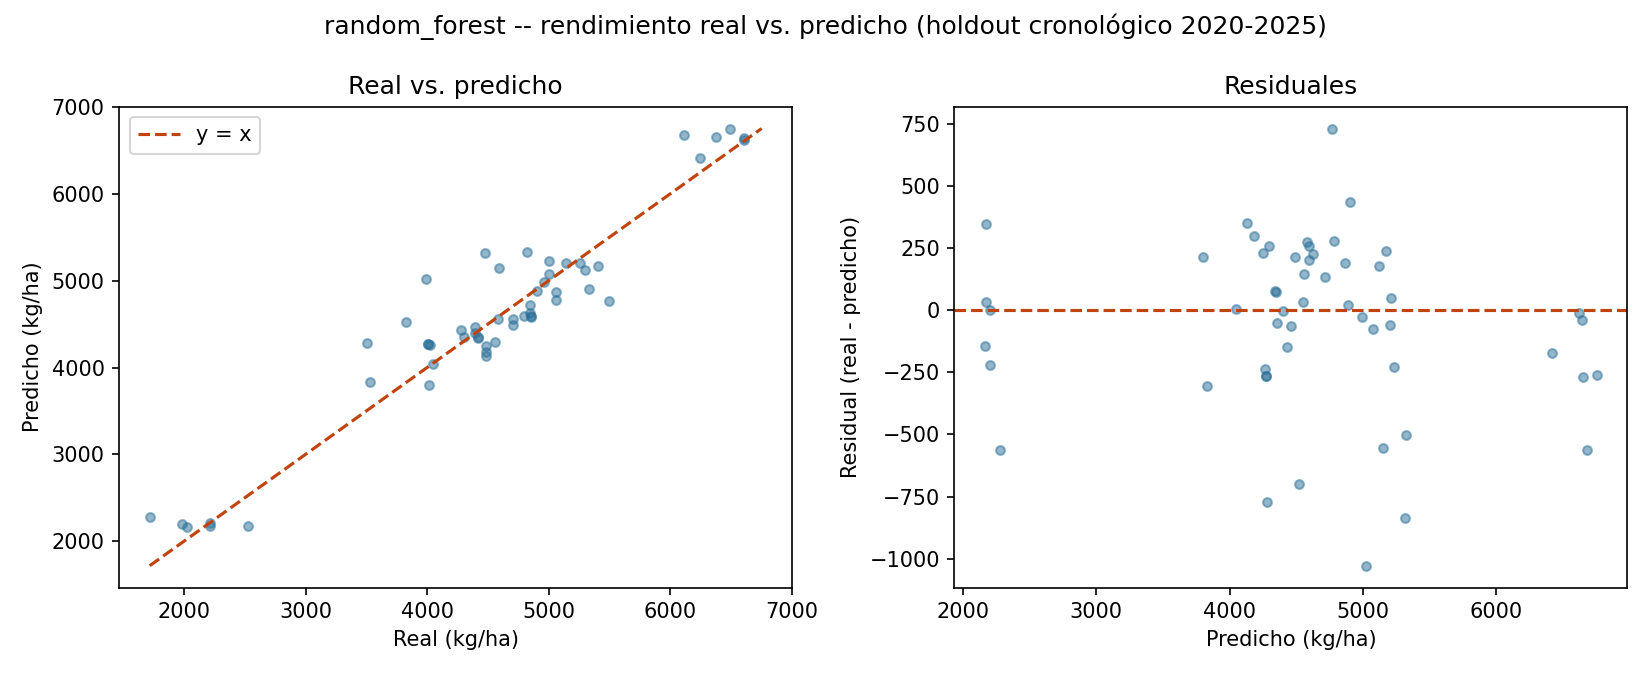

In [9]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/best_model_regression_diagnostics.png"))


**Comparación de los 6 modelos** -- los cinco modelos entrenados le ganan al baseline por un margen amplio; gana Random Forest.


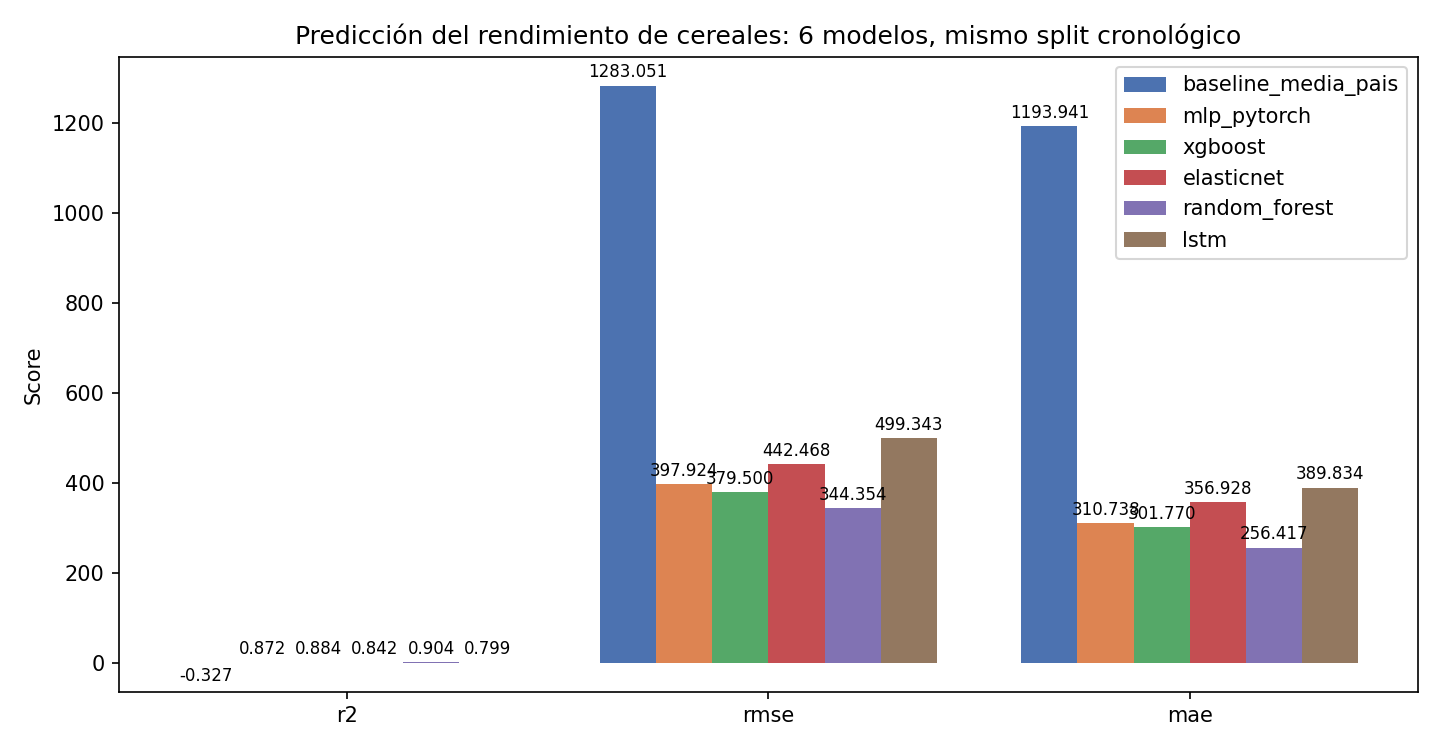

In [10]:
from IPython.display import Image, display
display(Image(filename="../outputs/agriculture/figures/model_comparison.png"))


## Conclusiones

- El panel agrícola tiene señal real y explotable (fertilizante, irrigación,
  tendencia agronómica) -- contraste honesto con el dominio financiero.
- La missingness no es uniforme: la mayoría de los huecos son bordes
  temporales triviales, pero un caso (Perú/irrigación) requiere imputación
  cross-país explícita, no interpolación.
